# Global Life Expectancy and Economic Development Analysis

## Project Overview

This project analyzes the relationship between life expectancy, GDP per capita, population, and continent-level development patterns using the Gapminder dataset.

The purpose of this notebook is to practice a complete data science workflow, including data loading, data cleaning, exploratory data analysis, visualization, and interpretation of findings.

## Research Questions

1. How has global life expectancy changed over time?
2. Is there a relationship between GDP per capita and life expectancy?
3. Which continents show higher or lower average life expectancy?
4. How do population and economic development differ across regions?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Source

This project uses the Gapminder dataset, which contains country-level information on life expectancy, GDP per capita, population, continent, and year.

The dataset is loaded directly from an online URL, so the notebook can be restarted and run without manually uploading any files.

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

print("Data loaded successfully.")
print("Shape of dataset:", df.shape)

df.head()

Data loaded successfully.
Shape of dataset: (1704, 6)


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## 2. Initial Data Inspection

Before conducting analysis, I first inspect the dataset structure, column types, missing values, and basic descriptive statistics.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   str    
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 103.7 KB


In [4]:
df.isnull().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

In [5]:
df.describe()

,year,pop,lifeExp,gdpPercap
count,1704.00000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,2.960121e+07,59.474439,7215.327081
std,17.26533,1.061579e+08,12.917107,9857.454543
min,1952.00000,6.001100e+04,23.599000,241.165876
25%,1965.75000,2.793664e+06,48.198000,1202.060309
50%,1979.50000,7.023596e+06,60.712500,3531.846988
75%,1993.25000,1.958522e+07,70.845500,9325.462346
max,2007.00000,1.318683e+09,82.603000,113523.132900


## 3. Data Cleaning and Feature Engineering

Although the dataset is already relatively clean, I still create a cleaned copy of the data and add several derived variables for analysis.

The new variables include:

- `gdp`: total GDP of each country-year observation
- `gdp_billion`: total GDP in billions
- `pop_million`: population in millions
- `log_gdpPercap`: logarithmic transformation of GDP per capita
- `decade`: decade grouping for long-term comparison

In [6]:
df_clean = df.copy()

# Create additional variables for analysis
df_clean["gdp"] = df_clean["gdpPercap"] * df_clean["pop"]
df_clean["gdp_billion"] = df_clean["gdp"] / 1_000_000_000
df_clean["pop_million"] = df_clean["pop"] / 1_000_000
df_clean["log_gdpPercap"] = np.log10(df_clean["gdpPercap"])
df_clean["decade"] = (df_clean["year"] // 10 * 10).astype(str) + "s"

# Check duplicated country-year records
duplicate_count = df_clean.duplicated(subset=["country", "year"]).sum()

print("Cleaned dataset shape:", df_clean.shape)
print("Number of duplicated country-year records:", duplicate_count)

df_clean.head()

Cleaned dataset shape: (1704, 11)
Number of duplicated country-year records: 0


,country,year,pop,continent,lifeExp,gdpPercap,gdp,gdp_billion,pop_million,log_gdpPercap,decade
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314,6.567086e+09,6.567086,8.425333,2.891786,1950s
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030,7.585449e+09,7.585449,9.240934,2.914265,1950s
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710,8.758856e+09,8.758856,10.267083,2.931000,1960s
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138,9.648014e+09,9.648014,11.537966,2.922309,1960s
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106,9.678553e+09,9.678553,13.079460,2.869221,1970s


## 4. Exploratory Data Analysis

### Research Question 1: How has global life expectancy changed over time?

To understand the long-term trend of health outcomes, I calculate both the simple average life expectancy and the population-weighted average life expectancy by year.

In [7]:
global_life_trend = (
    df_clean
    .groupby("year")
    .apply(lambda x: pd.Series({
        "avg_lifeExp": x["lifeExp"].mean(),
        "weighted_lifeExp": np.average(x["lifeExp"], weights=x["pop"])
    }))
    .reset_index()
)

global_life_trend

,year,avg_lifeExp,weighted_lifeExp
0,1952,49.057620,48.944237
1,1957,51.507401,52.121885
2,1962,53.609249,52.324382
3,1967,55.678290,56.984307
4,1972,57.647386,59.514783
5,1977,59.570157,61.237256
6,1982,61.533197,62.881755
7,1987,63.212613,64.416350
8,1992,64.160338,65.645900
9,1997,65.014676,66.849343


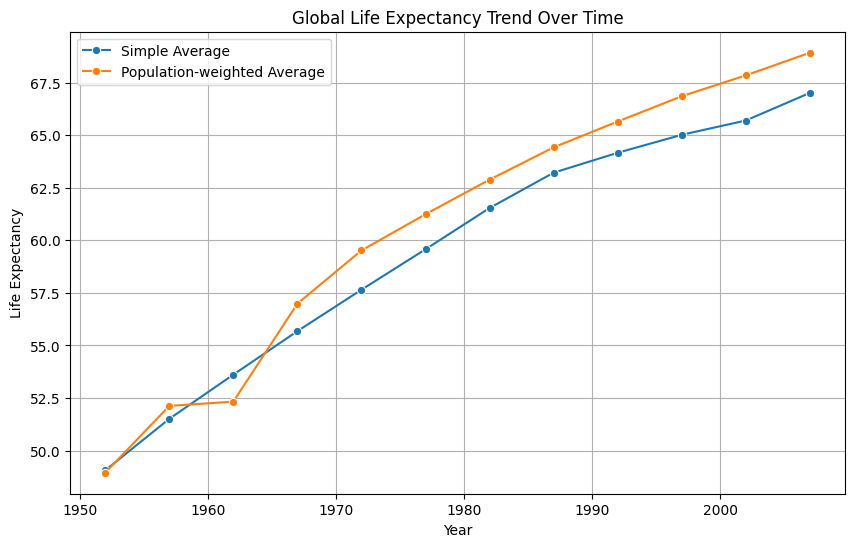

In [8]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=global_life_trend,
    x="year",
    y="avg_lifeExp",
    marker="o",
    label="Simple Average"
)

sns.lineplot(
    data=global_life_trend,
    x="year",
    y="weighted_lifeExp",
    marker="o",
    label="Population-weighted Average"
)

plt.title("Global Life Expectancy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.show()

### Finding 1

Global life expectancy shows a clear upward trend from 1952 to 2007. This suggests that overall health conditions improved significantly during the observed period.

The population-weighted average is useful because countries with larger populations have greater influence on the global result. Comparing the simple average and weighted average helps show whether improvements are broadly distributed across countries or concentrated in highly populated countries.

### Research Question 2: Is there a relationship between GDP per capita and life expectancy?

Next, I examine whether countries with higher GDP per capita tend to have higher life expectancy.

To avoid mixing different years together, I focus on the latest year in the dataset. I also use a logarithmic x-axis because GDP per capita is highly skewed.

In [9]:
latest_year = df_clean["year"].max()
df_latest = df_clean[df_clean["year"] == latest_year].copy()

print("Latest year in dataset:", latest_year)
print("Number of countries:", df_latest["country"].nunique())

df_latest.head()

Latest year in dataset: 2007
Number of countries: 142


,country,year,pop,continent,lifeExp,gdpPercap,gdp,gdp_billion,pop_million,log_gdpPercap,decade
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338,3.107929e+10,31.079292,31.889923,2.988818,2000s
23,Albania,2007,3600523.0,Europe,76.423,5937.029526,2.137641e+10,21.376411,3.600523,3.773569,2000s
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465,2.074449e+11,207.444852,33.333216,3.794025,2000s
47,Angola,2007,12420476.0,Africa,42.731,4797.231267,5.958390e+10,59.583896,12.420476,3.680991,2000s
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640,5.150336e+11,515.033625,40.301927,4.106510,2000s


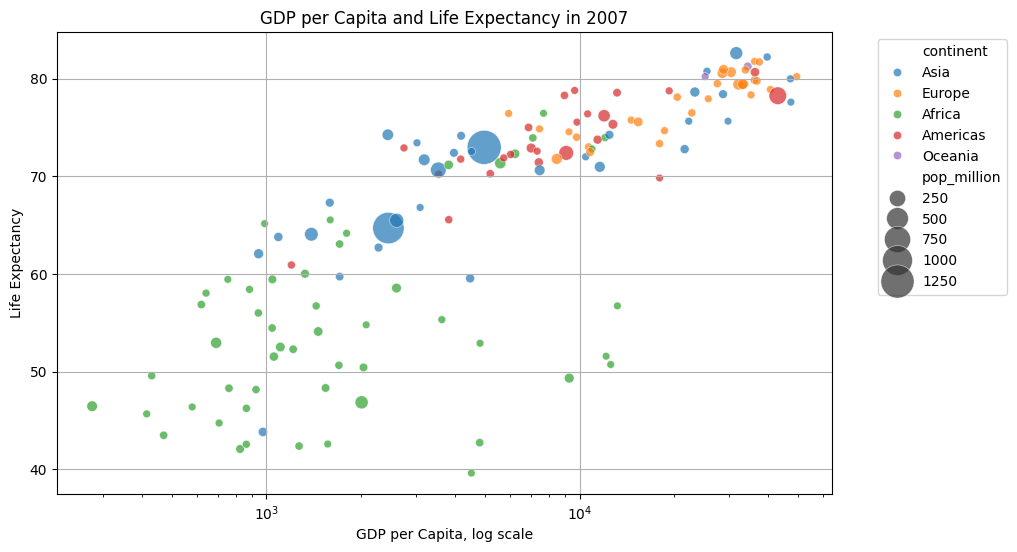

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_latest,
    x="gdpPercap",
    y="lifeExp",
    hue="continent",
    size="pop_million",
    sizes=(30, 600),
    alpha=0.7
)

plt.xscale("log")
plt.title(f"GDP per Capita and Life Expectancy in {latest_year}")
plt.xlabel("GDP per Capita, log scale")
plt.ylabel("Life Expectancy")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [11]:
correlation_latest = df_latest[["lifeExp", "gdpPercap", "log_gdpPercap", "pop_million"]].corr()

correlation_latest

,lifeExp,gdpPercap,log_gdpPercap,pop_million
lifeExp,1.000000,0.678662,0.808980,0.047553
gdpPercap,0.678662,1.000000,0.875109,-0.055676
log_gdpPercap,0.808980,0.875109,1.000000,-0.023530
pop_million,0.047553,-0.055676,-0.023530,1.000000


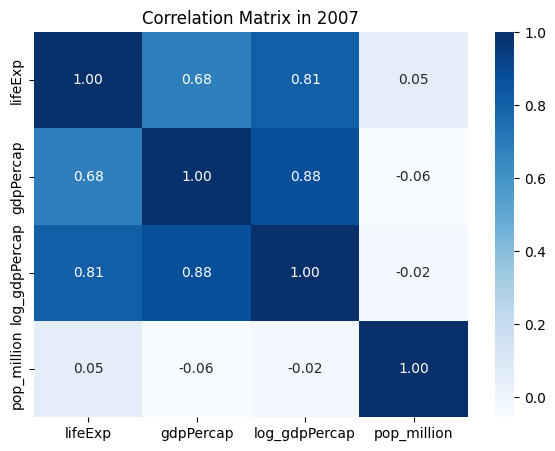

In [12]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_latest,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title(f"Correlation Matrix in {latest_year}")
plt.show()

### Finding 2

The scatter plot shows a positive relationship between GDP per capita and life expectancy. Countries with higher income levels generally tend to have longer life expectancy.

However, the relationship is not perfectly linear. After a certain income level, the increase in life expectancy becomes smaller, suggesting that economic development may have diminishing marginal effects on health outcomes.

The correlation matrix also shows that the logarithmic transformation of GDP per capita has a stronger relationship with life expectancy than raw GDP per capita. This supports the decision to use a log scale when visualizing the relationship.

### Research Question 3: Which continents show higher or lower average life expectancy?

In this section, I compare life expectancy across continents. This helps identify regional differences and shows whether global improvement is evenly distributed across the world.

In [13]:
continent_life_trend = (
    df_clean
    .groupby(["year", "continent"])
    .agg(
        avg_lifeExp=("lifeExp", "mean"),
        median_lifeExp=("lifeExp", "median"),
        avg_gdpPercap=("gdpPercap", "mean"),
        total_pop=("pop", "sum")
    )
    .reset_index()
)

continent_life_trend.head()

,year,continent,avg_lifeExp,median_lifeExp,avg_gdpPercap,total_pop
0,1952,Africa,39.135500,38.833,1252.572466,2.376405e+08
1,1952,Americas,53.279840,54.745,4079.062552,3.451524e+08
2,1952,Asia,46.314394,44.869,5195.484004,1.395357e+09
3,1952,Europe,64.408500,65.900,5661.057435,4.181208e+08
4,1952,Oceania,69.255000,69.255,10298.085650,1.068601e+07


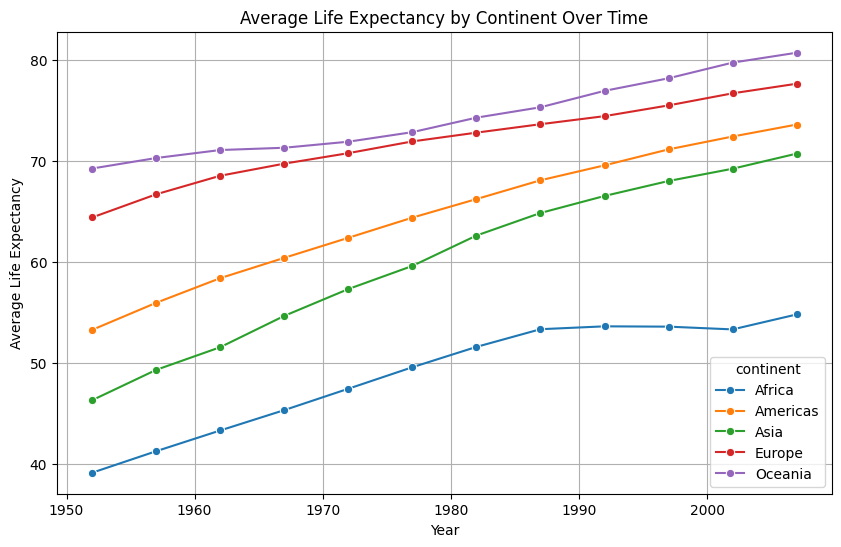

In [14]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=continent_life_trend,
    x="year",
    y="avg_lifeExp",
    hue="continent",
    marker="o"
)

plt.title("Average Life Expectancy by Continent Over Time")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.grid(True)
plt.show()

In [15]:
continent_latest_summary = (
    df_latest
    .groupby("continent")
    .agg(
        countries=("country", "nunique"),
        avg_lifeExp=("lifeExp", "mean"),
        median_lifeExp=("lifeExp", "median"),
        avg_gdpPercap=("gdpPercap", "mean"),
        total_population_million=("pop_million", "sum")
    )
    .reset_index()
    .sort_values("avg_lifeExp", ascending=False)
)

continent_latest_summary

,continent,countries,avg_lifeExp,median_lifeExp,avg_gdpPercap,total_population_million
4,Oceania,2,80.719500,80.7195,29810.188275,24.549947
3,Europe,30,77.648600,78.6085,25054.481636,586.098529
1,Americas,25,73.608120,72.8990,11003.031625,898.871184
2,Asia,33,70.728485,72.3960,12473.026870,3811.953827
0,Africa,52,54.806038,52.9265,3089.032605,929.539692


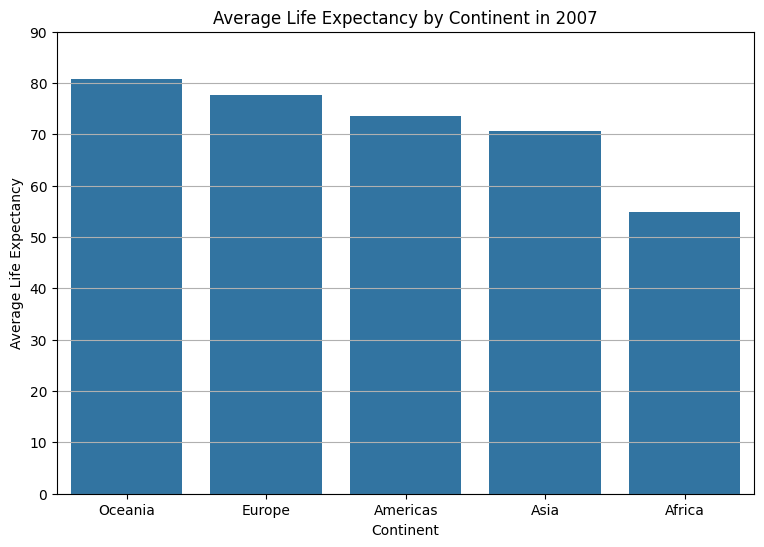

In [16]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=continent_latest_summary,
    x="continent",
    y="avg_lifeExp"
)

plt.title(f"Average Life Expectancy by Continent in {latest_year}")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")
plt.ylim(0, 90)
plt.grid(axis="y")
plt.show()

### Finding 3

Life expectancy increased across all continents from 1952 to 2007, but the level and speed of improvement differed by region.

In the latest year, Europe and Oceania show relatively high average life expectancy, while Africa remains lower compared with other continents. This suggests that global health improvement has been significant, but regional inequality still exists.

The continent-level comparison also shows that economic development and health outcomes are related, but regional factors such as healthcare access, political stability, infrastructure, and public health systems may also affect life expectancy.

### Research Question 4: How do population and economic development differ across regions?

Finally, I use a bubble chart to examine GDP per capita, life expectancy, population size, and continent at the same time.

In this visualization:

- X-axis represents GDP per capita
- Y-axis represents life expectancy
- Bubble size represents population
- Color represents continent

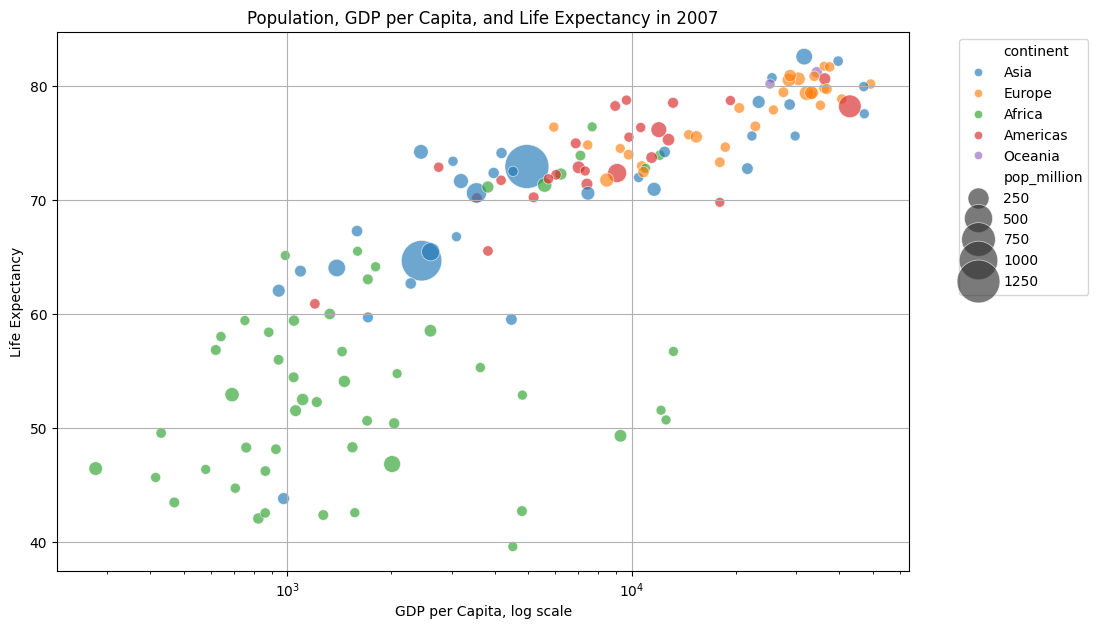

In [17]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_latest,
    x="gdpPercap",
    y="lifeExp",
    hue="continent",
    size="pop_million",
    sizes=(50, 1000),
    alpha=0.65
)

plt.xscale("log")
plt.title(f"Population, GDP per Capita, and Life Expectancy in {latest_year}")
plt.xlabel("GDP per Capita, log scale")
plt.ylabel("Life Expectancy")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [18]:
fig = px.scatter(
    df_clean,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year",
    animation_group="country",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=60,
    range_x=[100, 120000],
    range_y=[20, 90],
    title="Animated Relationship Between GDP per Capita and Life Expectancy"
)

fig.show()

### Finding 4

The bubble chart shows that countries with higher GDP per capita generally have higher life expectancy. However, population size adds another important perspective.

Some highly populated countries have large influence on the global pattern, while smaller countries may show extreme values but have less impact on the population-weighted global average.

The animated chart also shows that many countries moved upward over time, meaning life expectancy improved globally. At the same time, the horizontal movement toward higher GDP per capita differs across countries and continents, indicating uneven economic development.

## 5. Conclusion

This project analyzed the relationship between life expectancy, GDP per capita, population, continent, and time using the Gapminder dataset.

The analysis leads to four main conclusions:

1. Global life expectancy increased substantially from 1952 to 2007.
2. GDP per capita and life expectancy show a positive relationship, especially when GDP per capita is viewed on a logarithmic scale.
3. All continents experienced improvement, but regional inequality remained visible in the latest year.
4. Population size matters when interpreting global trends because highly populated countries have greater influence on population-weighted results.

Overall, the project shows that economic development is strongly associated with health outcomes, but income alone does not fully explain differences in life expectancy. Regional, social, institutional, and public health factors may also play important roles.

## 6. Limitations and Future Work

This analysis has several limitations.

First, the dataset only covers selected years from 1952 to 2007, so it does not reflect more recent global changes. Second, the analysis focuses mainly on correlation, so it cannot prove that GDP per capita directly causes higher life expectancy. Third, important variables such as healthcare quality, education, inequality, political stability, and public health policy are not included in the dataset.

For future work, the analysis could be extended by adding more recent data and additional social or institutional indicators. A more advanced model could also be used to examine which factors best predict life expectancy.